### **Lunar Lander PPO (TORCH)**

This is a working PPO implementation for LunarLander. Compared to the original notebook, this version adds the pieces that make PPO actually function:

- **Actor + Critic** (separate value network) — the original had no critic at all, which is why it didn't learn.
- **GAE-lambda advantages** instead of normalized raw returns. Advantages tell the policy *which actions were better than expected*, not just *which trajectories were good*.
- **Entropy bonus** to keep exploration alive (without it, the policy collapses to a single deterministic action).
- **Correct bootstrapping** at truncations and at the end of incomplete trajectories — episodes that didn't really terminate keep their bootstrap value.
- **Fixed test/render cell** that uses the actual policy (the original referenced `agent.action(state)` from a different notebook).

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import gymnasium as gym

import sys
sys.stderr = open('err.txt', 'w')

In [2]:
# --- Hyperparameters ---
gamma           = 0.99
gae_lambda      = 0.95        # GAE lambda for advantage smoothing
clip_ratio      = 0.2         # PPO clipping epsilon (typical: 0.1 - 0.3)
learning_rate_p = 3e-4        # policy lr
learning_rate_v = 1e-3        # value lr (commonly higher than policy lr)
epochs          = 10          # PPO update epochs per iteration
steps_per_epoch = 2048        # transitions collected per iteration
batch_size      = 64
entropy_coef    = 0.01        # entropy bonus weight
value_coef      = 0.5         # value loss weight (only used if you share the optimizer)
max_grad_norm   = 0.5         # global grad-norm clip
solved_threshold = 200
MAX_ITERATIONS  = 500         # PPO iterations (each one is a rollout + update)
EVAL_EPS        = 100          # eval episodes per iteration (smaller = faster training)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# Check GPU status
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    x = torch.randn(1000, 1000, device="cuda")
    y = x @ x
    print("Matmul on GPU OK, result shape:", y.shape)
else:
    print("Running on CPU.")

PyTorch version: 2.11.0+cu130
CUDA available: True
CUDA version: 13.0
  GPU 0: NVIDIA GB10
Matmul on GPU OK, result shape: torch.Size([1000, 1000])


In [4]:
env = gym.make("LunarLander-v3")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print(f"obs_dim={obs_dim}, n_actions={n_actions}")

obs_dim=8, n_actions=4


In [5]:
# --- Actor (Policy) and Critic (Value) networks ---
# Keeping them separate makes the code clearer; sharing a trunk would also work.

class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)        # raw logits, not probs


class ValueNetwork(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)    # (B,) not (B, 1)


policy = PolicyNetwork(obs_dim, n_actions).to(device)
value_net = ValueNetwork(obs_dim).to(device)

opt_policy = optim.Adam(policy.parameters(), lr=learning_rate_p)
opt_value  = optim.Adam(value_net.parameters(), lr=learning_rate_v)

In [6]:
# --- GAE-lambda advantage and return computation ---
def compute_gae(rewards, values, dones, last_value, gamma=0.99, lam=0.95):
    """
    Compute GAE-lambda advantages and lambda-returns for a rollout.
    
    rewards, values, dones: arrays of length T (the rollout)
    last_value: V(s_T), used to bootstrap whether the rollout ended terminally or was truncated.
                Pass 0.0 if the last step was a true terminal; pass V(s_last) otherwise.
    
    dones[t] = 1.0 if step t was a real terminal step (terminated=True), else 0.0.
               Truncations should NOT mark dones[t]=1 (we still bootstrap from the next state).
    
    Returns (advantages, returns), both arrays of length T.
    """
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            next_value = last_value
        else:
            next_value = values[t + 1]
        # If step t was terminal, the bootstrap is killed (mask = 0).
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * mask - values[t]
        gae = delta + gamma * lam * mask * gae
        advantages[t] = gae
    returns = advantages + values
    return advantages, returns

In [7]:
# --- Trajectory Collection ---
def collect_trajectories(env, policy, value_net, steps):
    obs_buf, act_buf, rew_buf, val_buf, logp_buf, done_buf = [], [], [], [], [], []
    
    obs, _ = env.reset()
    
    for t in range(steps):
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            logits = policy(obs_tensor)
            value  = value_net(obs_tensor).item()
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            logp = dist.log_prob(action).item()
            action = action.item()
        
        next_obs, reward, terminated, truncated, _ = env.step(action)
        
        obs_buf.append(obs)
        act_buf.append(action)
        rew_buf.append(reward)
        val_buf.append(value)
        logp_buf.append(logp)
        # Only TRUE termination kills the bootstrap. Truncation does not.
        done_buf.append(1.0 if terminated else 0.0)
        
        obs = next_obs
        if terminated or truncated:
            obs, _ = env.reset()
    
    # Bootstrap the last state's value (whether the rollout ended mid-episode or right at a reset)
    last_obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        last_value = value_net(last_obs_tensor).item()
    # If we just reset (the previous step was terminal or truncated), `obs` is a fresh state — 
    # `last_value` is its value, but it shouldn't affect the previous trajectory because dones[T-1]=1
    # for terminal, and for truncation we still bootstrap from V(obs_truncated). Acceptable approximation.
    
    rewards = np.array(rew_buf, dtype=np.float32)
    values  = np.array(val_buf, dtype=np.float32)
    dones   = np.array(done_buf, dtype=np.float32)
    
    advantages, returns = compute_gae(rewards, values, dones, last_value,
                                       gamma=gamma, lam=gae_lambda)
    
    return (
        np.array(obs_buf, dtype=np.float32),
        np.array(act_buf, dtype=np.int64),
        advantages,
        returns,
        np.array(logp_buf, dtype=np.float32),
    )

In [8]:
# --- PPO update step ---
def ppo_update(obs, act, advantages, returns, old_logp):
    # Normalize advantages (not returns!) - this is the standard trick
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
    obs        = torch.as_tensor(obs,        dtype=torch.float32, device=device)
    act        = torch.as_tensor(act,        dtype=torch.long,    device=device)
    advantages = torch.as_tensor(advantages, dtype=torch.float32, device=device)
    returns    = torch.as_tensor(returns,    dtype=torch.float32, device=device)
    old_logp   = torch.as_tensor(old_logp,   dtype=torch.float32, device=device)
    
    n = len(obs)
    
    for _ in range(epochs):
        indices = torch.randperm(n, device=device)
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            
            # Policy update
            logits = policy(obs[batch_idx])
            dist = torch.distributions.Categorical(logits=logits)
            new_logp = dist.log_prob(act[batch_idx])
            entropy = dist.entropy().mean()
            
            ratio = torch.exp(new_logp - old_logp[batch_idx])
            adv_b = advantages[batch_idx]
            
            surr1 = ratio * adv_b
            surr2 = torch.clamp(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio) * adv_b
            policy_loss = -torch.min(surr1, surr2).mean()
            
            # Entropy bonus: maximize entropy = minimize -entropy
            loss_actor = policy_loss - entropy_coef * entropy
            
            opt_policy.zero_grad()
            loss_actor.backward()
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_grad_norm)
            opt_policy.step()
            
            # Value update (regression onto lambda-returns)
            values_pred = value_net(obs[batch_idx])
            value_loss = ((values_pred - returns[batch_idx]) ** 2).mean()
            
            opt_value.zero_grad()
            value_loss.backward()
            torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_grad_norm)
            opt_value.step()

In [9]:
# --- Evaluation (stochastic, like training) ---
# For a stable eval signal we sample from the policy instead of taking the argmax.
# Pure argmax can look better than the policy actually is, especially early on.

def evaluate_policy(env, policy, n_episodes=10, deterministic=False):
    total_rewards = []
    for episode in range(n_episodes):
        obs, _ = env.reset(seed=10_000 + episode)
        done = False
        ep_reward = 0.0
        while not done:
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                logits = policy(obs_tensor)
                if deterministic:
                    action = torch.argmax(logits, dim=-1).item()
                else:
                    dist = torch.distributions.Categorical(logits=logits)
                    action = dist.sample().item()
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        total_rewards.append(ep_reward)
    return float(np.mean(total_rewards)), float(np.std(total_rewards))

In [10]:
# --- Training loop ---
avg_reward_per_iter = []
start_time = time.time()

for it in range(MAX_ITERATIONS):
    # 1. Roll out the policy
    obs_b, act_b, adv_b, ret_b, logp_b = collect_trajectories(
        env, policy, value_net, steps_per_epoch
    )
    
    # 2. PPO update
    ppo_update(obs_b, act_b, adv_b, ret_b, logp_b)
    
    # 3. Evaluate (stochastic policy)
    mean_r, std_r = evaluate_policy(env, policy, n_episodes=EVAL_EPS, deterministic=False)
    avg_reward_per_iter.append(mean_r)
    
    elapsed = (time.time() - start_time) / 60.0
    print(f"Iter {it+1:3d}/{MAX_ITERATIONS}  "
          f"avg reward ({EVAL_EPS} eps): {mean_r:7.2f} ± {std_r:5.1f}  "
          f"elapsed: {elapsed:.1f} min")
    
    if mean_r >= solved_threshold:
        print(f"\nEnvironment solved in {it+1} iterations!")
        break

print(f"\nTraining done in {(time.time()-start_time)/60:.2f} minutes.")

Iter   1/500  avg reward (100 eps): -170.61 ±  89.7  elapsed: 0.1 min
Iter   2/500  avg reward (100 eps): -138.85 ±  88.4  elapsed: 0.1 min
Iter   3/500  avg reward (100 eps): -149.79 ±  99.6  elapsed: 0.2 min
Iter   4/500  avg reward (100 eps): -156.43 ±  94.0  elapsed: 0.2 min
Iter   5/500  avg reward (100 eps): -146.63 ±  95.0  elapsed: 0.3 min
Iter   6/500  avg reward (100 eps): -136.21 ±  83.5  elapsed: 0.4 min
Iter   7/500  avg reward (100 eps): -118.31 ±  89.9  elapsed: 0.4 min
Iter   8/500  avg reward (100 eps): -106.43 ±  96.8  elapsed: 0.5 min
Iter   9/500  avg reward (100 eps):  -80.56 ±  79.9  elapsed: 0.6 min
Iter  10/500  avg reward (100 eps):  -48.88 ±  59.6  elapsed: 0.7 min
Iter  11/500  avg reward (100 eps):  -42.19 ±  59.4  elapsed: 0.7 min
Iter  12/500  avg reward (100 eps):  -20.91 ±  53.0  elapsed: 0.8 min
Iter  13/500  avg reward (100 eps):  -15.73 ±  43.4  elapsed: 0.9 min
Iter  14/500  avg reward (100 eps):   -3.74 ±  51.3  elapsed: 1.0 min
Iter  15/500  avg re

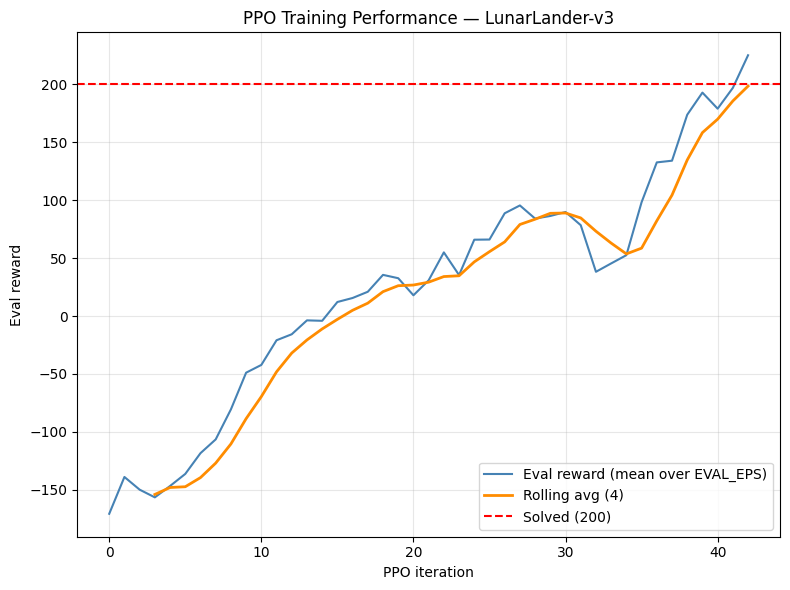

In [15]:
# Plot rewards
plt.figure(figsize=(8, 6))
plt.plot(avg_reward_per_iter, label='Eval reward (mean over EVAL_EPS)', color='steelblue')

# Rolling average
window = min(10, max(1, len(avg_reward_per_iter)//10))
if len(avg_reward_per_iter) >= window:
    rolling = np.convolve(avg_reward_per_iter, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(avg_reward_per_iter)), rolling,
             label=f'Rolling avg ({window})', color='darkorange', linewidth=2)

plt.axhline(y=solved_threshold, color='red', linestyle='--', label=f'Solved ({solved_threshold})')
plt.title('PPO Training Performance — LunarLander-v3')
plt.xlabel('PPO iteration')
plt.ylabel('Eval reward')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Test for 10 episodes using the trained policy (deterministic)
# Use deterministic=True here for a clean demonstration of what the agent does
# when it commits to its best guess.

start_time = time.time()
test_rewards = []

for e_test in range(10):
    state, _ = env.reset()
    total_reward = 0.0
    steps = 0
    while True:
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            logits = policy(state_tensor)
        action = torch.argmax(logits, dim=-1).item()
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        steps += 1
        total_reward += reward
        if terminated or truncated:
            print(f"Test Episode {e_test+1:2d}/10  Reward: {total_reward:+8.2f}  "
                  f"Steps: {steps:4d}  Terminated: {terminated}")
            test_rewards.append(total_reward)
            break

print(f"\nMean test reward: {np.mean(test_rewards):.2f}")
print(f"Testing completed in {(time.time()-start_time)/60:.2f} minutes")

Test Episode  1/10  Reward:  +215.94  Steps:  378  Terminated: True
Test Episode  2/10  Reward:  +277.94  Steps:  429  Terminated: True
Test Episode  3/10  Reward:  +277.66  Steps:  383  Terminated: True
Test Episode  4/10  Reward:  +256.47  Steps:  400  Terminated: True
Test Episode  5/10  Reward:  +246.65  Steps:  411  Terminated: True
Test Episode  6/10  Reward:  +202.42  Steps:  367  Terminated: True
Test Episode  7/10  Reward:  +256.29  Steps:  355  Terminated: True
Test Episode  8/10  Reward:  +254.32  Steps:  407  Terminated: True
Test Episode  9/10  Reward:  +257.95  Steps:  324  Terminated: True
Test Episode 10/10  Reward:  +206.17  Steps:  396  Terminated: True

Mean test reward: 245.18
Testing completed in 0.00 minutes


#### **Render one episode as a GIF**

In [13]:
# Render a single test episode and save as GIF.
from PIL import Image

render_env = gym.make("LunarLander-v3", render_mode='rgb_array')
frames = []

state, _ = render_env.reset()
total_reward = 0.0

while True:
    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        logits = policy(state_tensor)
    action = torch.argmax(logits, dim=-1).item()
    
    next_state, reward, terminated, truncated, _ = render_env.step(action)
    frames.append(render_env.render())
    total_reward += reward
    state = next_state
    
    if terminated or truncated:
        print(f"Rendered episode reward: {total_reward:.2f}")
        break

render_env.close()

def save_frames_as_gif(frames, path='./', filename='LunarLander_PPO.gif'):
    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:],
                   duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")

save_frames_as_gif(frames, filename='LunarLander_PPO.gif')

Rendered episode reward: 243.06
Saved GIF to: ./LunarLander_PPO.gif
